In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("cleaned_data.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.2 KB


In [6]:
# Regression target
y_reg = df["charges"]

# Features
X = df.drop("charges", axis=1)

print("Features (X):")
print(X.head())

Features (X):
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest


In [7]:
# Classification target

median_charge = y_reg.median()

y_clf = (y_reg > median_charge).astype(int)

print("Median Charge:", median_charge)
print(y_clf.value_counts())

Median Charge: 9386.1613
charges
0    669
1    668
Name: count, dtype: int64


In [8]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [9]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1069, 8)
Testing Shape: (268, 8)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


In [11]:
# Train Linear Regression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_reg_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [12]:
# Predictions

y_pred_reg = linear_model.predict(X_test_scaled)

In [13]:
# Evaluation

mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 35478020.67523558
R² Score: 0.8069287081198013


In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,age,3472.975553
1,bmi,1927.828251
2,children,636.501185
3,sex_male,-50.749675
4,smoker_yes,9234.342487
5,region_northwest,-168.944439
6,region_southeast,-371.780810
7,region_southwest,-284.610396


In [15]:
top3 = coefficients.copy()

top3["Absolute"] = top3["Coefficient"].abs()

top3 = top3.sort_values("Absolute", ascending=False)

print(top3.head(3))

      Feature  Coefficient     Absolute
4  smoker_yes  9234.342487  9234.342487
0         age  3472.975553  3472.975553
1         bmi  1927.828251  1927.828251


In [16]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_reg_train)

print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


In [17]:
ridge_pred = ridge_model.predict(X_test_scaled)

In [18]:
ridge_mse = mean_squared_error(y_reg_test, ridge_pred)
ridge_r2 = r2_score(y_reg_test, ridge_pred)

print("Ridge Mean Squared Error:", ridge_mse)
print("Ridge R² Score:", ridge_r2)

Ridge Mean Squared Error: 35512474.828305505
Ridge R² Score: 0.8067412087126404


In [19]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

comparison

,Model,MSE,R² Score
0,Linear Regression,3.547802e+07,0.806929
1,Ridge Regression,3.551247e+07,0.806741


In [20]:
print("Training Class Distribution:")
print(y_clf_train.value_counts())

Training Class Distribution:
charges
0    537
1    532
Name: count, dtype: int64


In [21]:
class_percentage = y_clf_train.value_counts(normalize=True) * 100
print(class_percentage)

charges
0    50.233863
1    49.766137
Name: proportion, dtype: float64


In [22]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_clf_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [23]:
# Predict Class Labels

y_pred_clf = logistic_model.predict(X_test_scaled)

# Predict Probabilities

y_prob_clf = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [24]:
cm = confusion_matrix(y_clf_test, y_pred_clf)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[117  15]
 [  9 127]]


In [25]:
print(classification_report(y_clf_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       132
           1       0.89      0.93      0.91       136

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



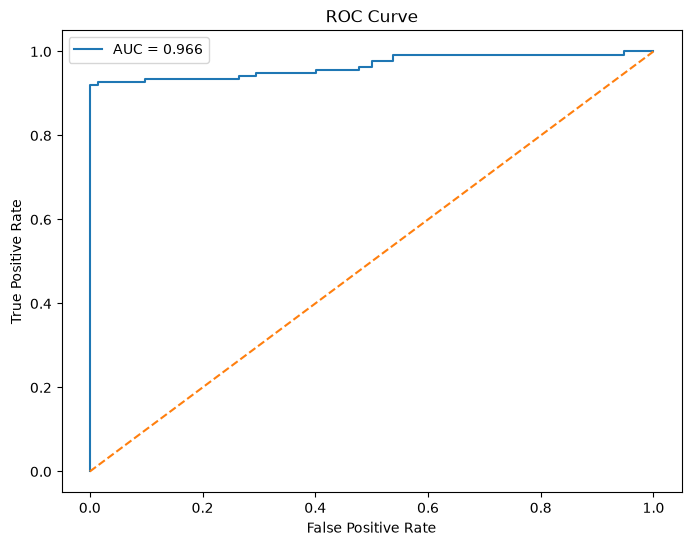

AUC Score: 0.9663547237076648


In [26]:
fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob_clf)

auc = roc_auc_score(y_clf_test, y_prob_clf)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", auc)

In [27]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:
    predictions = (y_prob_clf >= threshold).astype(int)

    precision = precision_score(y_clf_test, predictions)
    recall = recall_score(y_clf_test, predictions)
    f1 = f1_score(y_clf_test, predictions)

    results.append([threshold, precision, recall, f1])

threshold_table = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

threshold_table

,Threshold,Precision,Recall,F1 Score
0,0.3,0.780488,0.941176,0.853333
1,0.4,0.841060,0.933824,0.885017
2,0.5,0.894366,0.933824,0.913669
3,0.6,0.992063,0.919118,0.954198
4,0.7,1.000000,0.838235,0.912000


In [28]:
logistic_model_smallC = LogisticRegression(
    C=0.01,
    max_iter=1000
)

logistic_model_smallC.fit(X_train_scaled, y_clf_train)

y_prob_smallC = logistic_model_smallC.predict_proba(X_test_scaled)[:,1]

y_pred_smallC = logistic_model_smallC.predict(X_test_scaled)

auc_smallC = roc_auc_score(y_clf_test, y_prob_smallC)

precision_smallC = precision_score(y_clf_test, y_pred_smallC)
recall_smallC = recall_score(y_clf_test, y_pred_smallC)

In [29]:
comparison = pd.DataFrame({
    "Model": ["Logistic (C=1.0)", "Logistic (C=0.01)"],
    "Precision": [
        precision_score(y_clf_test, y_pred_clf),
        precision_smallC
    ],
    "Recall": [
        recall_score(y_clf_test, y_pred_clf),
        recall_smallC
    ],
    "AUC": [
        auc,
        auc_smallC
    ]
})

comparison

,Model,Precision,Recall,AUC
0,Logistic (C=1.0),0.894366,0.933824,0.966355
1,Logistic (C=0.01),0.906475,0.926471,0.965575


In [31]:
import numpy as np

auc_differences = []

for i in range(500):

    indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    y_true = y_clf_test.iloc[indices]

    prob1 = y_prob_clf[indices]
    prob2 = y_prob_smallC[indices]

    auc1 = roc_auc_score(y_true, prob1)
    auc2 = roc_auc_score(y_true, prob2)

    auc_differences.append(auc1 - auc2)

mean_difference = np.mean(auc_differences)

lower = np.percentile(auc_differences, 2.5)

upper = np.percentile(auc_differences, 97.5)

print("Mean AUC Difference:", mean_difference)
print("95% Confidence Interval:")
print("Lower:", lower)
print("Upper:", upper)

Mean AUC Difference: 0.0008186394267057302
95% Confidence Interval:
Lower: -0.0012281464837672813
Upper: 0.0030915057198179323
